In [1]:
import sys
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.lpcmci import LPCMCI
from tigramite.data_processing import DataFrame
from tigramite.plotting import plot_graph
from statsmodels.tsa.stattools import adfuller
from tigramite.independence_tests.parcorr import ParCorr
import warnings
import os
import json
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.append('../')




In [2]:
# Ensure the folder exists
folder_path = 'visual'
os.makedirs(folder_path, exist_ok=True)
save_type = ".eps"
dpi = 400

In [3]:
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna(), autolag='AIC')
    p_value = result[1]
    return p_value < 0.01  # If p-value is less than 0.01, the series is stationary

# Function to make the series stationary
def make_stationary(df, max_diff=1):

    """
    Transforms the columns of a DataFrame to be stationary using iterative differencing.

    For each column in the input DataFrame, this function:
    - Ignores columns with constant values.
    - Checks if the series is already stationary via `check_stationarity()`; if so, includes as-is.
    - Otherwise, applies differencing up to `max_diff` times, stopping if the series becomes stationary.
    - Includes the resulting stationary series (if any) in the output DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with time series columns to be made stationary.
    max_diff : int, default=1
        Maximum number of differencing steps to attempt for each column.

    Returns
    -------
    stationary_df : pd.DataFrame
        DataFrame containing transformed stationary columns (possibly with fewer rows due to differencing).
        Columns that are constant are omitted.

    Notes
    -----
    - Requires the function `check_stationarity(series)` to be defined elsewhere; this should return True if the input series is stationary.
    - The output may have missing values at the beginning of each column due to differencing, which are retained as NaN or may be trimmed by dropna.

    Examples
    --------
    >>> stationary_df = make_stationary(df, max_diff=2)
    """
    stationary_df = pd.DataFrame()
    
    # Check stationarity of each column
    for column in df.columns:
        series = df[column].dropna()
        
        # Check if the series is constant
        # Constant columsna are dropped
        if series.nunique() == 1:
            continue
        
        # Check if the series is already stationary
        if check_stationarity(series):
            stationary_df[column] = series
            continue
        
        differenced_series = series.copy()
        
        # Apply differencing up to max_diff times
        for d in range(1, max_diff + 1):
            differenced_series = differenced_series.diff().dropna()
            if check_stationarity(differenced_series):
                break
        
        # Store the stationary series in the DataFrame
        stationary_df[column] = differenced_series
    
    return stationary_df



In [4]:
current_path = Path(__file__).resolve().parent if '__file__' in globals() else Path().resolve()
path = current_path.parent / "data" / "gold" / "experiment_1"

#path

In [ ]:


folders_to_search = ["simulation", "dc2_1", "dc2_2", "dc1", "minidc"]

# Assuming 'path' is already defined as in your code

graphs = []

for search_term in folders_to_search:
    # List all directories in 'path' that contain the search_term in their name (case-insensitive)
    folders_with_term = [
        f for f in os.listdir(path) 
        if os.path.isdir(os.path.join(path, f)) and search_term.lower() in f.lower()
    ]
    
    if folders_with_term:
        first_folder = folders_with_term[0]
        print(f"First folder containing '{search_term}': {first_folder}")
        graphs.append(first_folder)
    else:
        print(f"No folder containing '{search_term}' found in the path.")
        # Optionally, append None or skip
        graphs.append(None)

print("Graphs list:", graphs)

First folder containing 'simulation': exp_15_simulation_prepared__df_sim_3__f02_g1
First folder containing 'dc2_1': exp_28_dc2_1_prepared__df_h__f06_g1
First folder containing 'dc2_2': exp_31_dc2_2_prepared__df_5m__f1_g1
First folder containing 'dc1': exp_62_dc1_prepared__df_rack_3__f08_g1
First folder containing 'minidc': exp_56_minidc_prepared__df_exp_3__f1_g1
Graphs list: ['exp_15_simulation_prepared__df_sim_3__f02_g1', 'exp_28_dc2_1_prepared__df_h__f06_g1', 'exp_31_dc2_2_prepared__df_5m__f1_g1', 'exp_62_dc1_prepared__df_rack_3__f08_g1', 'exp_56_minidc_prepared__df_exp_3__f1_g1']


First folder containing 'simulation': exp_15_simulation_prepared__df_sim_3__f02_g1
First folder containing 'dc2_1': exp_28_dc2_1_prepared__df_h__f06_g1
First folder containing 'dc2_2': exp_31_dc2_2_prepared__df_5m__f1_g1
First folder containing 'dc1': exp_62_dc1_prepared__df_rack_3__f08_g1
First folder containing 'minidc': exp_47_minidc_prepared__df_exp_2__f08_g1
['In_Temp', 'In_Hum', 'HVAC_Ener', 'ITE_Ener', 'Hour', 'Out_Temp', 'Out_Hum', 'Out_Wind', 'Out_Wind_Dir', 'Cool_Set', 'IT_Load']


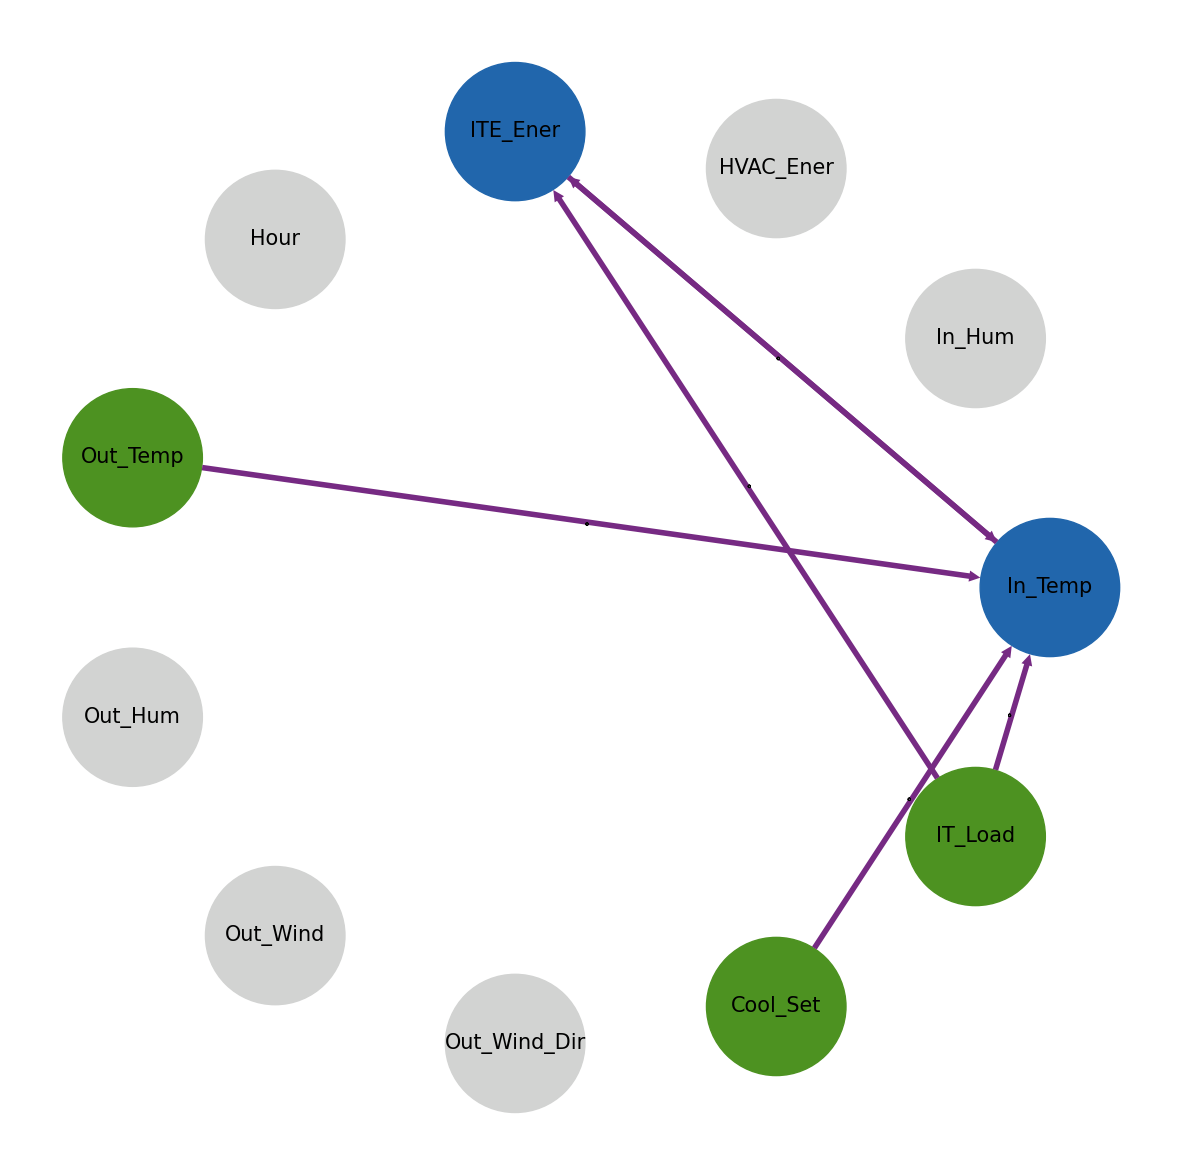

['cool_val_U1', 'cool_val_U3', 'cool_val_U4', 'fan_U1', 'fan_U4', 'hum_U1', 'hum_U2', 'hum_U4', 'line_A_watt', 'line_B_C_watt', 'line_D_E_watt', 'line_F_G_watt', 'line_H_I_watt', 'temp_in_U1', 'temp_in_U2', 'temp_in_U3', 'temp_in_U4', 'temp_out_U1', 'temp_out_U2', 'temp_out_U3', 'temp_out_U4', 'temperature_2m', 'relative_humidity_2m', 'apparent_temperature', 'precipitation', 'wind_speed_10m', 'wind_direction_100m', 'global_tilted_irradiance', 'hour']


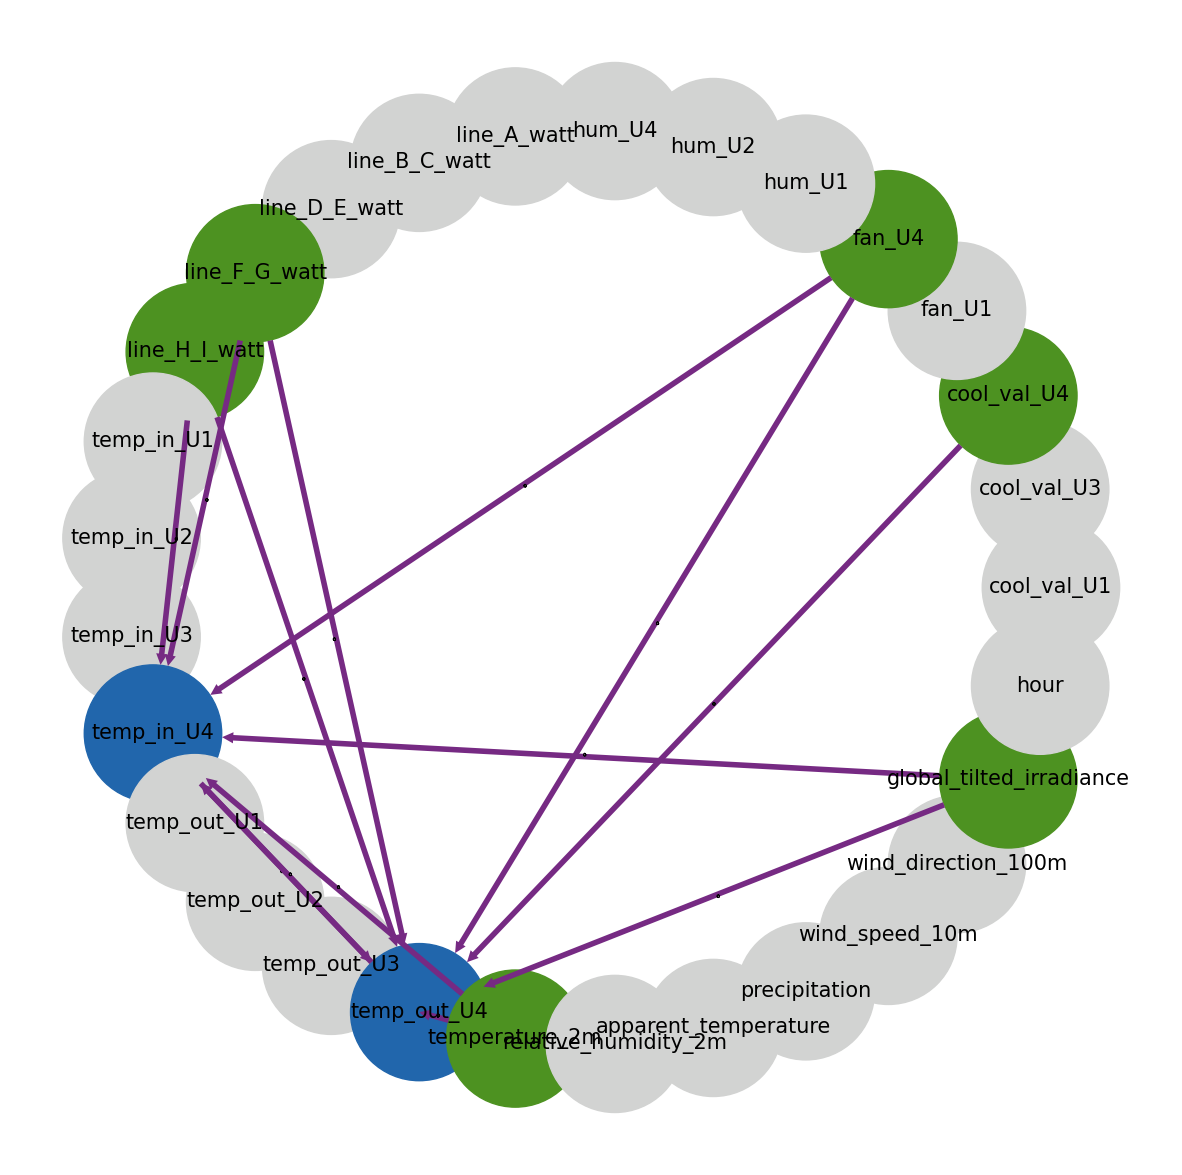

['cool_val_U1', 'cool_val_U3', 'cool_val_U4', 'fan_U1', 'fan_U4', 'hum_U1', 'hum_U2', 'line_A_watt', 'line_B_C_watt', 'line_D_E_watt', 'line_F_G_watt', 'line_H_I_watt', 'temp_in_U1', 'temp_in_U2', 'temp_in_U3', 'temp_in_U4', 'temp_out_U1', 'temp_out_U2', 'temp_out_U3', 'temp_out_U4']


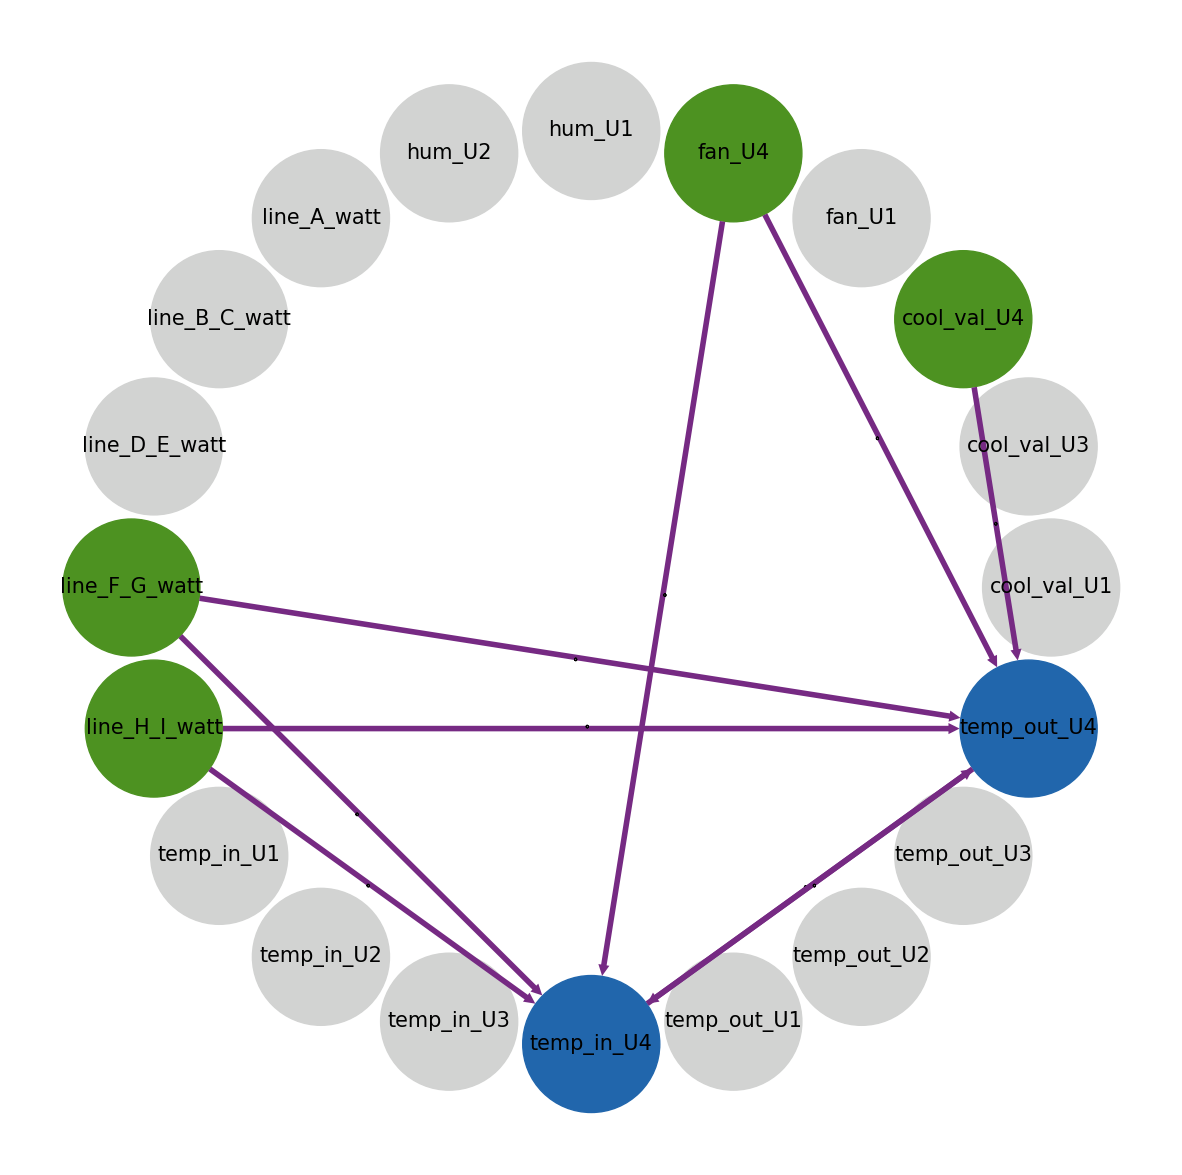

['flow--t_air_pbox', 'flow--t2', 'flow--t1', 'flow--t3_temp_customer_flow', 'flow--t4_temp_customer_return_flow', 'flow2--flow_ondemand_cooling', 'flow2--flow_primary', 'flow2--pres_blades_flow', 'flow2--pres_blades_return_flow', 'flow2--valve_3_tar', 'flow2--valve_4_tar', 'mean_cpu_util']


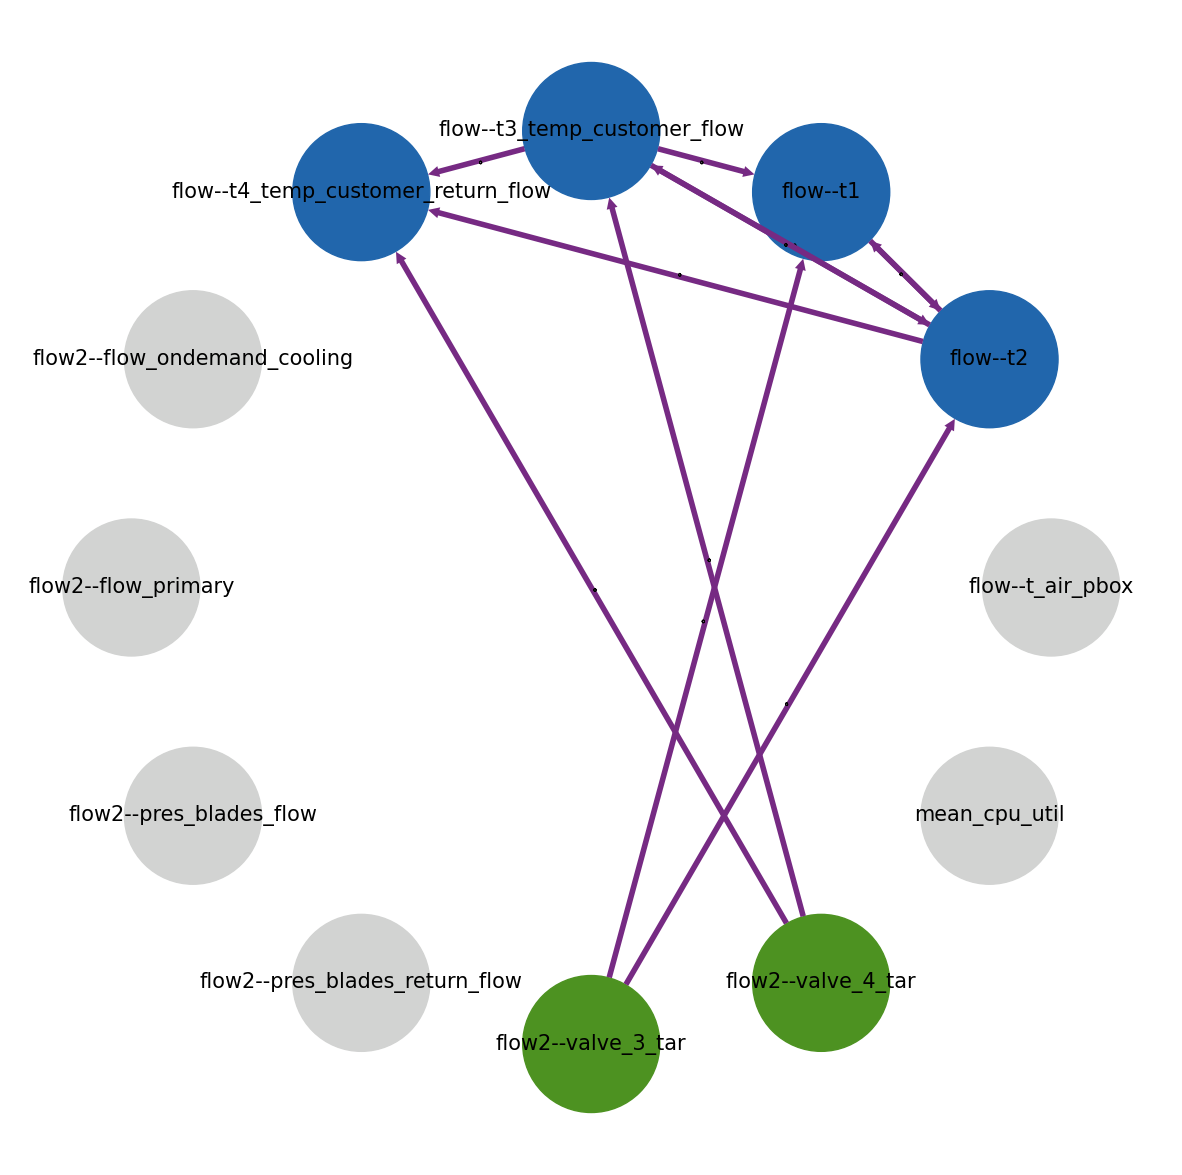

['cpu_temp_1', 'cpu_temp_2', 'env_humidity', 'env_pressure', 'env_temp', 'dc_fan', 'dc_pump', 'house_fan', 'house_pump', 'stress_ctrl', 'water_temp_house', 'water_temp_in_HEX', 'water_temp_out_HEX']


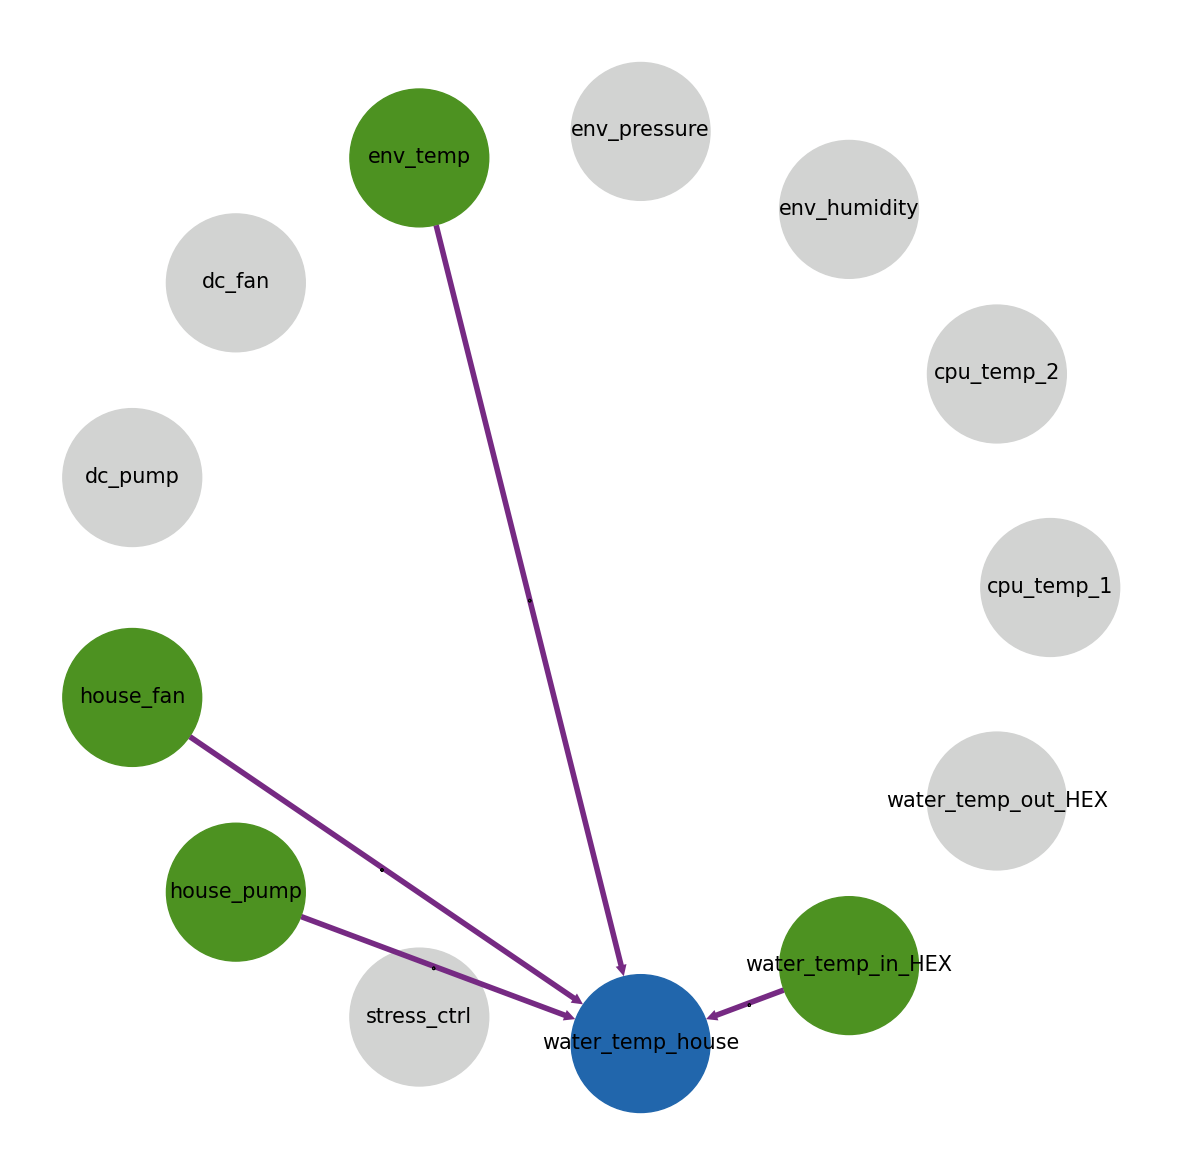

In [6]:



folders_to_search = {"simulation":0, "dc2_1":0, "dc2_2":0, "dc1":0, "minidc":1}

# Assuming 'path' is already defined as in your code
path = current_path.parent / "data" / "gold" / "experiment_1"

graphs = {}

for search_term, folder_num in folders_to_search.items():
    # List all directories in 'path' that contain the search_term in their name (case-insensitive)
    folders_with_term = [
        f for f in os.listdir(path) 
        if os.path.isdir(os.path.join(path, f)) and search_term.lower() in f.lower()
    ]
    
    if folders_with_term:
        folder = folders_with_term[folder_num]
        print(f"First folder containing '{search_term}': {folder}")
        graphs[search_term] = folder
    else:
        print(f"No folder containing '{search_term}' found in the path.")
        # Optionally, append None or skip
        graphs[search_term] = None

for graph_name, graph_link in graphs.items():

    json_path = path  / graph_link / "lag_1_edited_all" / "graph.json"
    with open(json_path, 'r') as file:
        graph_human = json.load(file)

    var_names = [key.split(') ')[1].strip() for key in graph_human.keys()]
    print(var_names)

    # === Colormaps ===
    # keep node colormap normal
    cmap_nodes = LinearSegmentedColormap.from_list(
        "EmeraldNavy", ["#2166ac", "lightgrey", "#4d9221"]
    )

    # --- Violet-colored edges using hex "#762a83"
    cmap_edges = LinearSegmentedColormap.from_list(
        "EdgeMapViolet", ["#762a83", "#762a83"]
    )

    # Number of variables
    N = len(var_names)

    # Set tau_max to 1 since only lag 1 is present
    tau_max = 1

    # Initialize the graph array
    graph = np.full((N, N, tau_max + 1), '', dtype='<U3')

    # Populate the graph array from graph_human
    val_matrix = np.zeros_like(graph, dtype=float)
    
    # First pass: set up graph structure and color parents (blue)
    for key, links in graph_human.items():
        i = int(key.split(')')[0][1:])  # Extract index (child)
        for link in links:
            var_j, lag = link  # var_j is parent
            j = var_names.index(var_j)
            tau = abs(lag)  # Convert -1 to 1
            if tau <= tau_max:
                graph[j, i, tau] = '-->'  # Reverse: parent --> child
                graph[j, j, tau] = '-->'  # color the circle of the parent
                val_matrix[j, j, tau] = 1  # parent gets blue (1)

    # Second pass: color targets (children) - this ensures they're always green
    for key, links in graph_human.items():
        if links:  # Only if node has incoming links (is a target/child)
            i = int(key.split(')')[0][1:])  # Extract index (child)
            val_matrix[i, i, tau_max] = -1  # child gets green (-1), overwrites any parent coloring

    # Now plot the graph
    fig, ax = tp.plot_graph(
            graph=graph,
            val_matrix=val_matrix,
            var_names=var_names,
            show_autodependency_lags=False,
            cmap_nodes=cmap_nodes,
            cmap_edges=cmap_edges,
            show_colorbar=False,
            figsize=(15, 15),
            arrow_linewidth=4,
            curved_radius=-0,
            label_fontsize=20,
            tick_label_size=15,
            node_label_size=15,
            arrowhead_size=300,
            link_label_fontsize=0
        )
    figure_filename = os.path.join(current_path, "visual/graph_" + graph_name + '.eps')
    plt.savefig(figure_filename, bbox_inches="tight", pad_inches=0.2, dpi=dpi)
    plt.show()